## Streaming processing of the QUAX experiment data with Dask and Kafka

## Overview

In this project, we build a real-time ETL (Extract-Transform-Load) pipeline for streaming data produced by the DAQ of the QUAX experiment, a resonant RF cavity used in axion dark matter searches. The DAQ produces scans consisting of the In-phase (I) and Quadrature (Q) components, which are two sinusoid functions in quadrature phase and together form a complex-valued time-domain signal (I + jQ). Processing this raw data consists of performing a Fourier transform on each scan to move from the time domain to the frequency domain, and then averaging all scans within a data-taking run to obtain a single averaged power spectrum. Each scan contains $2^{11} = 2048$ samples, and the FFT uses the same number of bins, while spanning a $2$ MHz bandwidth.

The dataset is composed of 2 sets of .dat binary files, one for the I measures and the other for the Q, each one comprised of a continuous series of ADC readings from the amplifier. Each ADC reading is written in the raw files as a 32-bit floating point value in little-endian format. Each file contains $2^{23}$ samples and its size is 32 MB. A realistic data production has a throughput of 16 MB/s and produces 1 file-pair every 5 seconds. 

## Architecture

The overall pipeline exploits Dask and Apache Kafka to perform the full real-time analysis. It consists of four main blocks:
- **Producer**: reads the raw I/Q `.dat` files and emulates a continuous DAQ stream, publishing batches of samples to Kafka with a configurable number of samples per batch and a configurable target throughput. It can be hosted in CloudVeneto or on our laptops, in order to compare performance across different network bandwidths.
- **Dask cluster**: consumes the raw batches from `topic_stream`, performs the FFT-based processing, and publishes the resulting power spectra to `topic_results`. It is deployed in CloudVeneto, and it hosts 1 scheduler node and up to 3 worker nodes.
- **Kafka broker**: acts as the decoupling layer between data management and processing, buffering the raw stream on `topic_stream` and the processed results on `topic_results`. It is hosted in the same CloudVeneto VM where the Dask scheduler sits.
- **Consumer**: subscribes to `topic_results` and renders a live-updating dashboard, showing both the per-worker spectra and the cumulative averaged spectrum. It is hosted on our laptops.

Kafka sits between the Producer and the Dask cluster, and again between the Dask cluster and the Consumer, so that each stage can run independently and at its own pace: a slowdown in processing does not block data ingestion, and a slowdown in visualization does not block processing. This decoupling also makes the pipeline horizontally scalable, since additional Dask workers can be added to increase processing throughput without changing the Producer or Consumer.

We set up Kafka `topic_stream` with a partition number equals to or larger than the number of workers. Indeed, each worker hosts a Kafka consumer and a Kafka producer, and we bypass the data streaming through the Dask scheduler which can be a potential bottleneck. This set up also allows the creation of a consumer group of worker nodes that process data in parallel, favouring the construction of an easy scalable system.

The communications between our laptops and the VMs in CloudVeneto are hold via ssh. We ofter rely on port forwarding, which allows to connect our laptops (localhost) with CloudVeneto.

Each CloudVeneto VM has 2 vCPUs and 4GB of RAM (*flavor: cloudveneto-medium*).

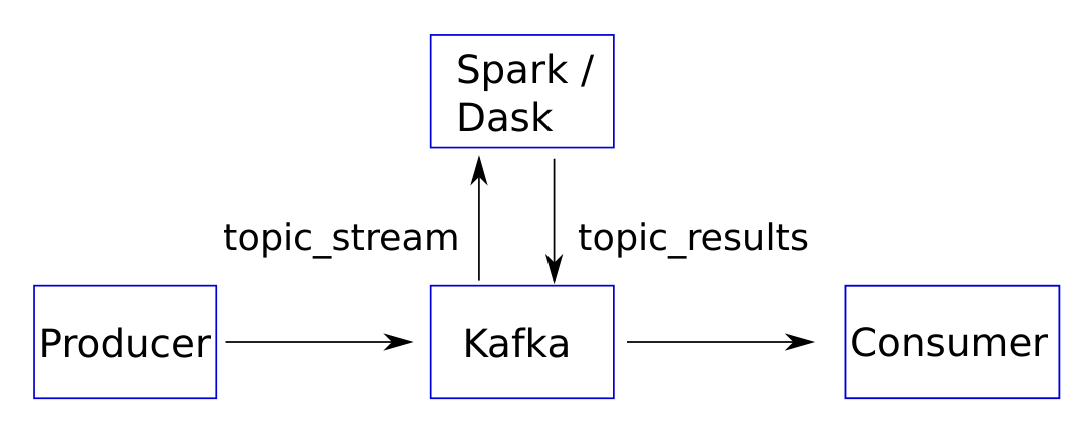

### Kafka Broker Settings

The Kafka broker is hosted on the same CloudVeneto virtual machine (VM) as the Dask scheduler. Below are the key configuration choices made to ensure the system operates smoothly, all of which are defined within the `kafka-server.properties` file used to start the Kafka broker:

* **Dual Network Listeners (`INTERNAL` / `EXTERNAL`)**: The broker exposes two separate communication channels on different ports. The `INTERNAL` listener (port 19092) is bound to the VM's private IP address (10.67.22.90) and handles all traffic within the CloudVeneto network, including communications with the Dask workers and the Producer. The `EXTERNAL` listener (port 9092) is advertised as `localhost`, allowing us to securely interact with the cluster from our personal laptops via an SSH tunnel.
* **Offset Replication Factor (`offsets.topic.replication.factor=1`)**: This parameter was set to 1, instead of the default value of 3. This adjustment is critical for a single-broker cluster: with the default value, Kafka would never be able to create the internal `__consumer_offsets` topic, which is essential for tracking data read states. Without this topic, Consumer Group coordination fails completely, causing consumers to hang indefinitely during the connection phase.
* **Data Retention Policies (`log.retention.*`)**: The log retention parameters were specifically tailored to the scale and duration of our tests. The total space limit was capped at approximately 192 MB (structured in 32 MB segments), while the time expiration was set to 30 minutes. Furthermore, we reduced the retention check frequency (`log.retention.check.interval.ms`) from the default 5 minutes to just 10 seconds. This responsiveness is necessary because the standard interval would not trigger the cleanup in time, leading to uncontrolled disk space growth and out-of-memory errors.
* **Large Payload Handling (`message.max.bytes`, `socket.*.bytes`)**: To prevent out-of-memory errors, the size limits for individual messages and network buffers (both receive and send) were raised to 100 MB. This capacity ensures the system to process the heaviest data batches, which can reach up to 64 MB in size plus the system headers.

```properties


# All settings are documented at https://kafka.apache.org/43/configuration/broker-configs/


# A comma-separated list of the names of the listeners used by the controller.
controller.listener.names=CONTROLLER

# The node id associated with this instance's roles
node.id=1

# The role of this server. Setting this puts us in KRaft mode
process.roles=broker,controller

# Listener name, hostname and port the broker or the controller will advertise to clients. INTERNAL refers to cloud VMs and EXTERNAL to our laptops
advertised.listeners=INTERNAL://10.67.22.90:19092,EXTERNAL://localhost:9092

# Disable the background thread checks the distribution of partition leaders at regular intervals. Not needed with a single broker
auto.leader.rebalance.enable=false

# List of controller endpoints used connect to the controller cluster
controller.quorum.bootstrap.servers=localhost:9093

# The address the socket server listens on
listeners=INTERNAL://0.0.0.0:19092,EXTERNAL://0.0.0.0:9092,CONTROLLER://0.0.0.0:9093

# A comma separated list of directories under which to store log files
log.dirs=/tmp/kraft-combined-logs

# The frequency in milliseconds that the log retention check is triggered. We set this to 10 seconds
log.retention.check.interval.ms = 10000

# The minimum age of a log file to be eligible for deletion due to age
log.retention.minutes=30

# A size-based retention policy for logs. Functions independently of log.retention.hours. We set this to the size of 6 files (192MB)
log.retention.bytes=201326592

# The maximum size of a log segment file. When this size is reached a new log segment will be created. We set this to 32MB
log.segment.bytes=33554432

# The largest record batch size allowed by Kafka. We set this to 100MB
message.max.bytes=104857600

# The receive buffer (SO_RCVBUF) used by the socket server
socket.receive.buffer.bytes=104857600

# The maximum size of a request that the socket server will accept (protection against OOM)
socket.request.max.bytes=104857600

# The send buffer (SO_SNDBUF) used by the socket server
socket.send.buffer.bytes=1048576

# Name of listener used for communication between brokers.
inter.broker.listener.name=INTERNAL

# Maps listener names to security protocols.
listener.security.protocol.map=CONTROLLER:PLAINTEXT,INTERNAL:PLAINTEXT,EXTERNAL:PLAINTEXT

# The replication factor for the offsets topic.
offsets.topic.replication.factor=1

### Network Throughput Analysis

We are interested in network throughput analysis since our architecture completely relies on network communications. Specifically, the rate can be bottlenecked by the underlying network infrastructure. To evaluate this, we measured the throughput using `iperf3`, an open-source tool that evaluates the throughput between two communicating machines. 

Here, we compare the network throughput between a local laptop and a CloudVeneto VM against the internal throughput between two CloudVeneto nodes. This analysis was crucial for determining the optimal deployment location for the producer. We have found the following results:

*   **Throughput between a local laptop and a CloudVeneto VM:** When measuring through an SSH tunnel, the throughput ranges between 8 MB/s and 25 MB/s. This performance is highly dependent on the local Internet connection and exhibits significant variability even within the same network, making it difficult to guarantee a constant target throughput of 16 MB/s. We corroborated these findings using `speedtest-cli`, a command that measures the internet bandwidth, yielding upload speeds between 12 MB/s and 16 MB/s. While these latter measurements do not account for the SSH tunnel overhead, they provide a reliable baseline estimate.
*   **Throughput between CloudVeneto nodes:** The internal throughput consistently ranges between 375 MB/s and 500 MB/s, representing a highly stable and capable network link. In this context, using `speedtest-cli` is not meaningful, as it measures the connection outside the cluster. 

Based on these findings, we deployed the producer directly within the CloudVeneto infrastructure rather than on a local machine, successfully ensuring an ideal 16 MB/s target throughput. Moreover, note that this network measurement is independent from the real throughput achieved by the Producer, which depends on other factors (see later).

Below, we report an excerpt of the terminal script with the tests performed on a local laptop:

```bash
dghezzi@PcDaniele:~/Project_MAPD$ iperf3 -c localhost -p 15201
Connecting to host localhost, port 15201
[  5] local 127.0.0.1 port 44338 connected to 127.0.0.1 port 15201
[ ID] Interval           Transfer     Bitrate         Retr  Cwnd
[  5]   0.00-1.02   sec  26.1 MBytes   215 Mbits/sec    5   1.19 MBytes
[  5]   1.02-2.02   sec  18.4 MBytes   154 Mbits/sec    3   1.19 MBytes
[  5]   2.02-3.00   sec  19.9 MBytes   170 Mbits/sec    3   1.19 MBytes
[  5]   3.00-4.01   sec  19.8 MBytes   165 Mbits/sec    5   1.19 MBytes
[  5]   4.01-5.01   sec  21.2 MBytes   178 Mbits/sec    4   1.19 MBytes
[  5]   5.01-6.00   sec  18.2 MBytes   153 Mbits/sec    3   1.19 MBytes
[  5]   6.00-7.00   sec  20.2 MBytes   170 Mbits/sec    6   1.19 MBytes
[  5]   7.00-8.00   sec  19.6 MBytes   165 Mbits/sec    5   1.19 MBytes
[  5]   8.00-9.00   sec  18.2 MBytes   153 Mbits/sec    4   1.19 MBytes
[  5]   9.00-10.05  sec  22.1 MBytes   178 Mbits/sec    5   1.19 MBytes
- - - - - - - - - - - - - - - - - - - - - - - - -
[ ID] Interval           Transfer     Bitrate         Retr
[  5]   0.00-10.05  sec   205 MBytes   171 Mbits/sec   43             sender
[  5]   0.00-9.69   sec   199 MBytes   172 Mbits/sec                  receiver

dghezzi@PcDaniele:~/Project_MAPD$ iperf3 -c localhost -p 15201
Connecting to host localhost, port 15201
[  5] local 127.0.0.1 port 60206 connected to 127.0.0.1 port 15201
[ ID] Interval           Transfer     Bitrate         Retr  Cwnd
[  5]   0.00-1.01   sec  24.2 MBytes   202 Mbits/sec    3   3.68 MBytes
[  5]   1.01-2.00   sec  14.2 MBytes   120 Mbits/sec    1   3.68 MBytes
[  5]   2.00-3.01   sec  13.0 MBytes   109 Mbits/sec    0   3.68 MBytes
[  5]   3.01-4.00   sec  9.50 MBytes  80.1 Mbits/sec    3   3.68 MBytes
[  5]   4.00-5.00   sec  13.6 MBytes   114 Mbits/sec    0   3.68 MBytes
[  5]   5.00-6.01   sec  12.9 MBytes   108 Mbits/sec    3   3.68 MBytes
[  5]   6.01-7.00   sec  13.2 MBytes   112 Mbits/sec    1   3.68 MBytes
[  5]   7.00-8.00   sec  11.5 MBytes  96.4 Mbits/sec    0   3.68 MBytes
[  5]   8.00-9.01   sec  13.6 MBytes   114 Mbits/sec    2   3.68 MBytes
[  5]   9.01-10.01  sec  13.2 MBytes   111 Mbits/sec    3   3.68 MBytes
- - - - - - - - - - - - - - - - - - - - - - - - -
[ ID] Interval           Transfer     Bitrate         Retr
[  5]   0.00-10.01  sec   139 MBytes   117 Mbits/sec   16             sender
[  5]   0.00-9.76   sec   131 MBytes   113 Mbits/sec                  receiver

dghezzi@PcDaniele:~/Project_MAPD$ speedtest-cli
Retrieving speedtest.net configuration...
Testing from Telecom Italia Business (79.1.175.151)...
Retrieving speedtest.net server list...
Selecting best server based on ping...
Hosted by Wolnet Srl (Verona) [71.61 km]: 25.428 ms
Testing download speed...................................................
Download: 122.60 Mbit/s
Testing upload speed.....................................................
Upload: 109.69 Mbit/s

Here we report the tests on the Producer virtual machine:

```bash
debian@mapd-group11-4:~$ iperf3 -c 10.67.22.90
Connecting to host 10.67.22.90, port 5201
[  5] local 10.67.22.236 port 60000 connected to 10.67.22.90 port 5201
[ ID] Interval           Transfer     Bitrate         Retr  Cwnd
[  5]   0.00-1.00   sec   468 MBytes  3.92 Gbits/sec  1039   1.54 MBytes
[  5]   1.00-2.00   sec   479 MBytes  4.02 Gbits/sec    0   1.74 MBytes
[  5]   2.00-3.00   sec   388 MBytes  3.25 Gbits/sec    0   1.84 MBytes
[  5]   3.00-4.00   sec   467 MBytes  3.92 Gbits/sec   17   1.48 MBytes
[  5]   4.00-5.00   sec   442 MBytes  3.71 Gbits/sec    0   1.67 MBytes
[  5]   5.00-6.00   sec   372 MBytes  3.12 Gbits/sec    0   1.76 MBytes
[  5]   6.00-7.00   sec   358 MBytes  3.00 Gbits/sec    0   1.85 MBytes
[  5]   7.00-8.00   sec   348 MBytes  2.91 Gbits/sec    0   1.91 MBytes
[  5]   8.00-9.00   sec   389 MBytes  3.26 Gbits/sec    0   2.04 MBytes
[  5]   9.00-10.00  sec   441 MBytes  3.70 Gbits/sec   64   1.63 MBytes
- - - - - - - - - - - - - - - - - - - - - - - - -
[ ID] Interval           Transfer     Bitrate         Retr
[  5]   0.00-10.00  sec  4.05 GBytes  3.48 Gbits/sec  1120            sender
[  5]   0.00-10.00  sec  4.05 GBytes  3.48 Gbits/sec                  receiver

### Producer

The Producer emulates the QUAX DAQ by reading pre-recorded I/Q raw data and streaming it to Kafka as if it were being acquired live. At the start, it loads the full set of `duck_i_*.dat`/`duck_q_*.dat` file pairs into memory as raw byte buffers, avoiding repeated disk I/O during the streaming loop.

The stream is then replayed in fixed-size batches, controlled by two configurable parameters:
- `SCANS_PER_BATCH`: the number of scans grouped into a single Kafka message.
- `TARGET_THROUGHPUT`: the target data rate (in bytes/s) the Producer tries to sustain, matching the real DAQ's rate of 16 MB/s.

For each batch, the I and Q byte slices are concatenated into a single payload and published to `topic_stream`, together with a set of headers (producer timestamp, target throughput, and scans per batch) used downstream for latency benchmarking. Then the Producer calls `send()` and `flush()`: the first function append in a memory buffer the batch and returns a future object, while the second function pushes all the buffered messages to the broker and wait for their acknowledgment. This logic allows to implement a control over the pacing of each batch, necessary to reliably fix `SCANS_PER_BATCH` and `TARGET_THROUGHPUT` as independent variables rather than letting Kafka's internal batching logic determine them implicitly.

The Producer can be run either from a team member's laptop (connecting to Kafka's `EXTERNAL` listener through an SSH tunnel) or from a dedicated VM inside CloudVeneto (connecting directly to the `INTERNAL` listener), which allowed us to compare achievable throughput under a home connection versus a faster CloudVeneto's internal network.

In [ ]:
from kafka import KafkaProducer
import glob
import sys
import time
import os
import datetime

print("Initializing kafka producer")

# =============================================================================
# Configuration
# =============================================================================
KAFKA_TOPIC = "topic_stream"
BOOTSTRAP_SERVERS = "localhost:9092"

'''
# to see Kafka debug logs
import logging
logging.basicConfig(level=logging.DEBUG)
logging.getLogger("kafka").setLevel(logging.DEBUG)
'''

# =============================================================================
# Kafka Producer Setup
# =============================================================================
# All settings explained in https://kafka-python.readthedocs.io/en/master/apidoc/KafkaProducer.html
producer = KafkaProducer(
    bootstrap_servers=BOOTSTRAP_SERVERS,
    #client_id                  # Appears in server-side logs. Default: ‘kafka-python-producer-#’ (appended with a unique number per instance)
    key_serializer = None,      # Send raw bytes
    value_serializer = None,    # Send raw bytes
    #transactional_id           # Not needed
    enable_idempotence = True,  # Ensure that exactly one copy of each message is written in the stream (Commented out for kafka-python-ng compatibility)
    #delivery_timeout_ms        # Not needed
    #acks = 0,                  # Use default all
    compression_type=None,      # No compression
    #retries                    # Not needed
    batch_size = 0,             # Disable batching, we will do our own
    #linger_ms                  # Not needed, batching is disabled
    #partitioner                # Use default
    #connections_max_idle_ms    # Use default
    max_block_ms = 3000,                        # Max block time if buffer is full
    max_request_size = 68*1024*1024,           # The maximum size of a request. This is also effectively a cap on the maximum record size. Note that the server has its own cap on record size which may be different from this
    max_in_flight_requests_per_connection = 1, # Requests are pipelined to kafka brokers up to this number of maximum requests per broker connection
    security_protocol = "PLAINTEXT",    
)

producer.partitions_for(KAFKA_TOPIC) # Warm up the producer to fetch cluster metadata

# =============================================================================
# Data Loading
# =============================================================================
# Locate and pair the I and Q data files
i_files = sorted(glob.glob("data/duck_i_*.dat"))
q_files = sorted(glob.glob("data/duck_q_*.dat"))
assert len(i_files) == len(q_files) == 31
files_count = len(i_files)

# Ensure file size matches expectations
FILE_SIZE = os.path.getsize(i_files[0])
assert FILE_SIZE == 33554432
HALF_TOTAL_SIZE = FILE_SIZE * files_count

print("Loading files...\n")

# Pre-allocate large bytearrays to hold all I and Q data in memory
i_data = bytearray(HALF_TOTAL_SIZE)
q_data = bytearray(HALF_TOTAL_SIZE)

# Read files sequentially directly into the pre-allocated buffers
for idx, (i_file, q_file) in enumerate(zip(i_files, q_files)):
    sys.stdout.write(f"\rLoading files {idx + 1}/{len(i_files)}")
    sys.stdout.flush()

    start = idx * FILE_SIZE
    end = start + FILE_SIZE

    # Read I data
    with open(i_file, "rb") as f:
        n = f.readinto(memoryview(i_data)[start:end])
        assert n == FILE_SIZE

    # Read Q data
    with open(q_file, "rb") as f:
        n = f.readinto(memoryview(q_data)[start:end])
        assert n == FILE_SIZE
print("\n")

# =============================================================================
# Streaming Parameters
# =============================================================================
SCANS_PER_BATCH = 4096
TARGET_THROUGHPUT = 16*1024*1024 # Target throughput in Bytes/s (16384 = 16 kB/s, final target will be 16777216 for 16 MB/s)

SAMPLES_PER_SCAN = 2048
SAMPLES_PER_BATCH = SCANS_PER_BATCH * SAMPLES_PER_SCAN
HALF_BATCH_SIZE = 4 * SAMPLES_PER_BATCH # 4 bytes per float32 sample

# Time to wait between batch transmissions to maintain TARGET_THROUGHPUT
TARGET_PUBLISH_INTERVAL = 2 * HALF_BATCH_SIZE / TARGET_THROUGHPUT

n_batches = HALF_TOTAL_SIZE // HALF_BATCH_SIZE

print(f"Streaming {n_batches} batches of size {2*HALF_BATCH_SIZE}B...")

# =============================================================================
# Main Streaming Loop
# =============================================================================
try:
    start_time = time.perf_counter()
    
    for i in range(n_batches):
        # Calculate slicing indices for the current batch
        start = i * HALF_BATCH_SIZE
        end = start + HALF_BATCH_SIZE

        # Extract I and Q bytes for this batch
        i_bytes = i_data[start:end]
        q_bytes = q_data[start:end]

        packet = i_bytes + q_bytes # Concatenate I and Q into a single packet
        
        timestamp = time.time()
        print(f"[{datetime.datetime.fromtimestamp(timestamp)}] Sending batch {i+1}/{n_batches} (scans up to {(i+1)*SCANS_PER_BATCH})")

        # Send packet to Kafka and measure the time for sending
        future = producer.send(
            KAFKA_TOPIC, 
            value=packet, 
            headers=[('producer_ts', str(timestamp).encode('utf-8')), ('throughput', str(TARGET_THROUGHPUT).encode('utf-8'))] # Attach metadata
        )
        producer.flush()

        # Calculate the target time and sleep if necessary to maintain the target publish interval
        target_time = start_time + (i + 1) * TARGET_PUBLISH_INTERVAL
        sleep_time = target_time - time.perf_counter()
        
        if sleep_time > 0:
            time.sleep(sleep_time)
        else:
            # If processing and network I/O took longer than the interval, warn about falling behind
            print(f"missed send by {sleep_time}s")
            
finally:
    print("Closing producer...")
    producer.close()

print("\nDone streaming.")

### Dask Cluster 

The Dask cluster is deployed in CloudVeneto, and it consists of a scheduler node and few worker nodes. The scheduler hosts the Kafka broker

### Consumer